In [1]:
# importamos las librerías que necesitamos

# Tratamiento de datos
# -----------------------------------------------------------------------
import pandas as pd

# Visualización
# ------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('C:/Users/maria/Desktop/adalab/pair_programming_modulo03_transformando_datos/world_data_full_apply_nulos.csv')

In [20]:
df.sample(5)  

,Unnamed: 0,country,density,abbreviation,agricultural_land,land_area,armed_forces_size,birth_rate,calling_code,capital/major_city,co2-emissions,cpi,cpi_change,currency-code,fertility_rate,forested_area,gasoline_price,gdp,gross_primary_education_enrollment,gross_tertiary_education_enrollment,infant_mortality,largest_city,life_expectancy,maternal_mortality_ratio,minimum_wage,official_language,out_of_pocket_health_expenditure,physicians_per_thousand,population,population_labor_force_participation,tax_revenue,total_tax_rate,unemployment_rate,urban_population,latitude,longitude,continent
107,107,Marshall Islands,329.00,MH,63.9,181.000,NaN,29.03,692.0,Majuro,143.000,NaN,NaN,USD,4.05,70.2,1.44,2.212780e+08,84.7,23.7,27.4,Majuro,65.2,NaN,2.00,Marshallese,10.0,0.42,58.791,NaN,17.8,65.9,NaN,45.514,7.131474,171.184478,Oceania
106,106,Malta,1.38,MT,32.4,316.000,2.0,9.20,356.0,Valletta,1.342,113.45,1.6,EUR,1.23,1.1,1.36,1.478616e+10,105.0,54.3,6.1,Birkirkara,82.3,6.0,5.07,Maltese,37.1,2.86,502.653,56.5,26.2,44.0,3.47,475.902,35.937496,14.375416,Europe
176,176,Tonga,147.00,TO,45.8,747.000,NaN,24.30,676.0,Nuku����,128.000,121.09,7.4,TOP,3.56,12.5,NaN,4.503533e+08,116.3,6.4,13.4,Nuku����,70.8,52.0,NaN,Tongan Language,10.2,0.52,100.209,59.8,22.3,27.5,1.12,24.145,-21.178986,-175.198242,Oceania
130,130,Oman,16.00,OM,4.6,309.500,47.0,19.19,968.0,Muscat,63.457,113.53,0.1,OMR,2.89,0.0,0.45,7.698309e+10,103.4,38.0,9.8,Seeb,77.6,19.0,4.33,Arabic,6.4,2.00,NaN,72.4,2.5,27.4,2.67,NaN,21.473533,55.975413,Asia
115,115,Montenegro,47.00,ME,19.0,13.812,12.0,11.73,382.0,Podgorica,2.017,116.32,2.6,EUR,1.75,61.5,1.16,5.494737e+09,100.0,56.1,2.3,Podgorica,76.8,6.0,1.23,Montenegrin language,31.8,2.76,622.137,54.4,NaN,22.2,14.88,417.765,42.708678,19.374390,Europe


In [3]:
df.columns

Index(['Unnamed: 0', 'country', 'density', 'abbreviation', 'agricultural_land',
       'land_area', 'armed_forces_size', 'birth_rate', 'calling_code',
       'capital/major_city', 'co2-emissions', 'cpi', 'cpi_change',
       'currency-code', 'fertility_rate', 'forested_area', 'gasoline_price',
       'gdp', 'gross_primary_education_enrollment',
       'gross_tertiary_education_enrollment', 'infant_mortality',
       'largest_city', 'life_expectancy', 'maternal_mortality_ratio',
       'minimum_wage', 'official_language', 'out_of_pocket_health_expenditure',
       'physicians_per_thousand', 'population',
       'population_labor_force_participation', 'tax_revenue', 'total_tax_rate',
       'unemployment_rate', 'urban_population', 'latitude', 'longitude',
       'continent'],
      dtype='object')

In [5]:
df['birth_rate'].describe().T

count    189.000000
mean      20.214974
std        9.945774
min        5.900000
25%       11.300000
50%       17.950000
75%       28.750000
max       46.080000
Name: birth_rate, dtype: float64

¿Cómo se distribuye la tasa de natalidad en el conjunto de datos? ¿Hay algún patrón evidente?

<Axes: xlabel='birth_rate', ylabel='Count'>

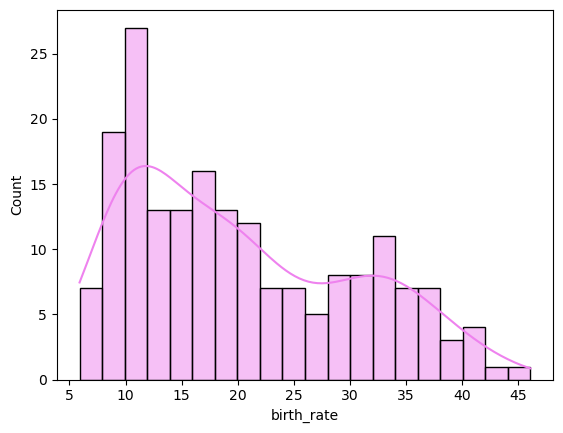

In [6]:
sns.histplot(x = "birth_rate", 
             data = df, 
             color = "violet", 
             kde = True, 
             bins = 20 )

 Representa la tasa de natalidad, que va aproximadamente desde 5 hasta 45 (probablemente nacimientos por cada 1,000 habitantes).
 La moda se encuentra entre 10-15
 distribución desigual y  una segunda concentración al rededor de 30-35.
 El eje count nos suma el numero de paises que tienen esa tasa.

¿Existe una relación aparente entre la tasa de mortalidad infantil y la esperanza de vida? Proporciona una breve descripción de los patrones que observes.

Text(0, 0.5, 'Esperanza de vida')

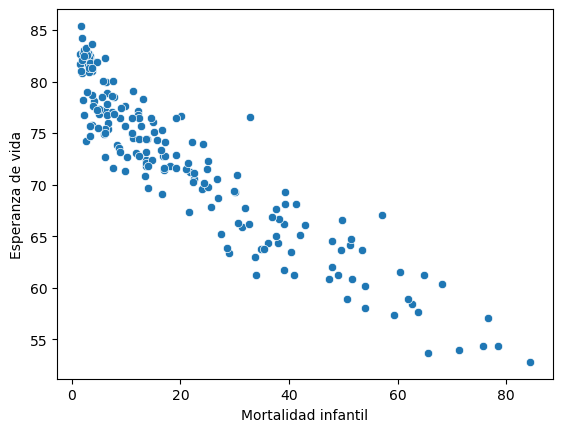

In [10]:
sns.scatterplot(x = "infant_mortality",
                y = "life_expectancy",
                data = df)

# cambiamos los nombres de los ejes
plt.xlabel("Mortalidad infantil")
plt.ylabel("Esperanza de vida")

El gráfico muestra que la mortalidad infantil es el factor más restrictivo para la esperanza de vida. Cuando la mortalidad infantil es baja, la esperanza de vida es alta y estable. Cuando la mortalidad infantil aumenta, la esperanza de vida cae dramáticamente.

¿Cuál es la mediana de la esperanza de vida en Europa? Proporciona un rango intercuartil aproximado y verifica si existen valores atípicos.

<Axes: xlabel='life_expectancy'>

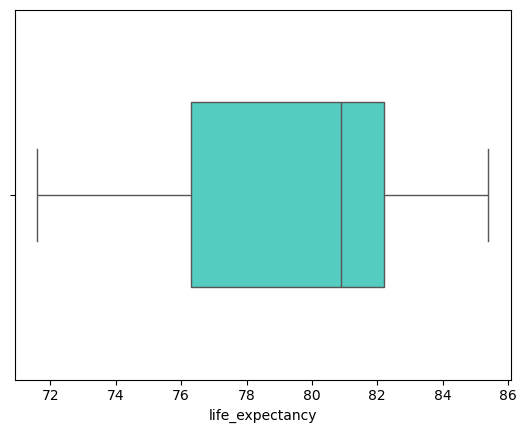

In [22]:
df_europa = df[df['continent'] == 'Europe']

sns.boxplot(x = df_europa['life_expectancy'], 
            width = 0.5, 
            color = "turquoise"
            )

No hay valores atipicos.
El 50% de los datos se escuentran entre 76 y 82.
La mediana sería 81.


¿Existen relaciones visibles entre la tasa de natalidad y las siguientes variables: tasa de mortalidad infantil, esperanza de vida, densidad de población y población urbana? Usa un subplot. Describe cualquier patrón que encuentres.

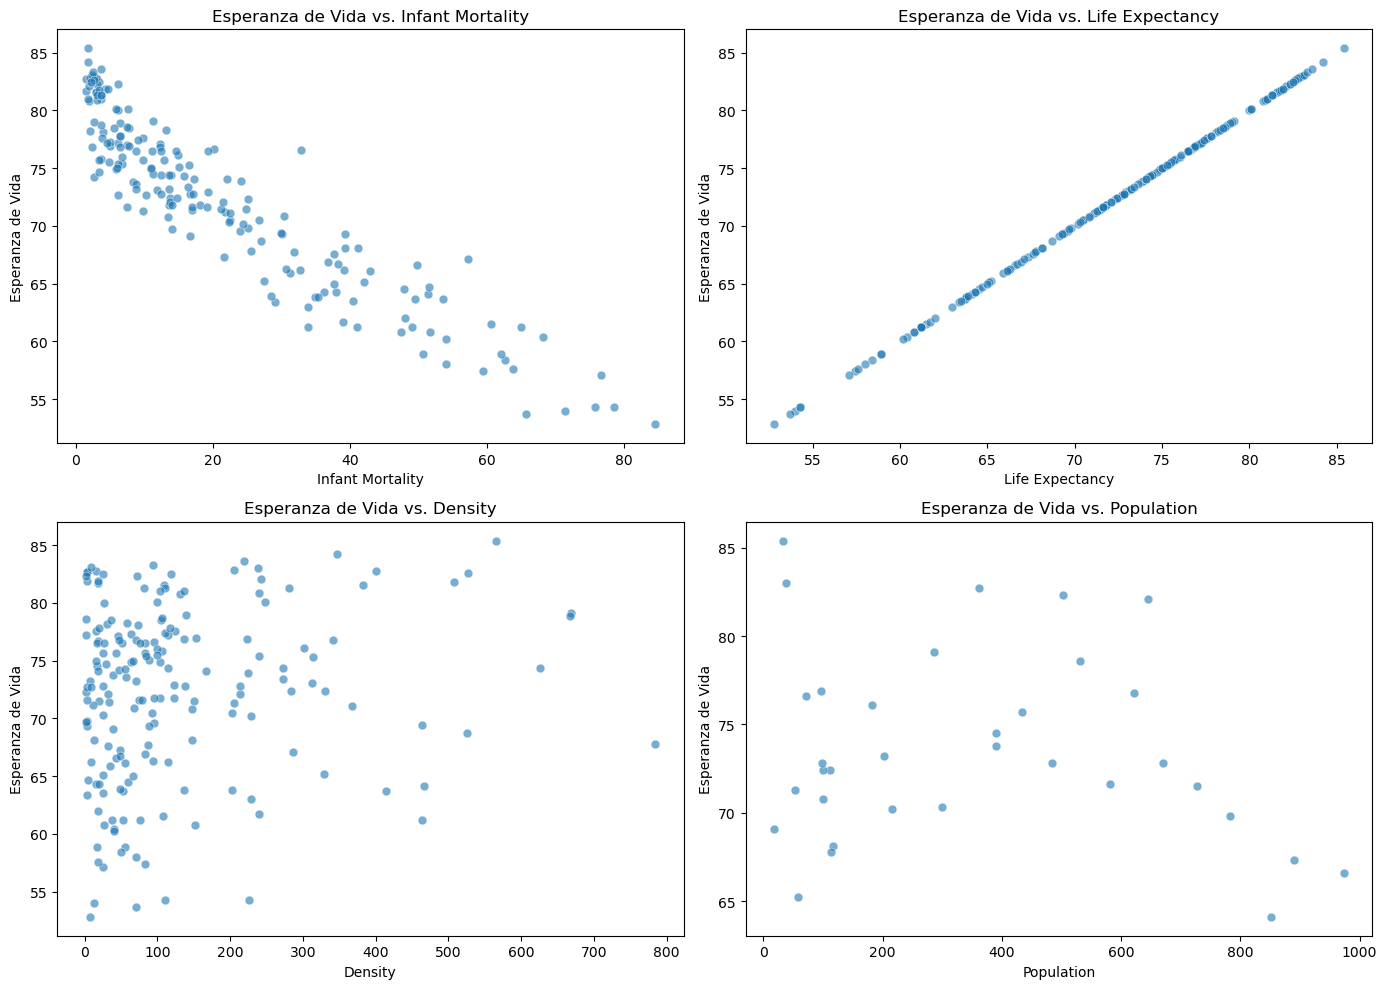

In [34]:
listavis = ['infant_mortality', 'life_expectancy', 'density', 'population'] # 1. Crea la cuadrícula de ejes 
fig, axes = plt.subplots(2, 2, figsize=(14, 10)) 
axes = axes.flatten() # Convierte la matriz de ejes en una lista plana # 2. Itera sobre las variables, dibuja y configura 
for i, var in enumerate(listavis): # Dibuja el scatterplot: Eje Y es 'life_expectancy' 
    sns.scatterplot( data=df, x=var, y='life_expectancy', # <-- Eje Y: Esperanza de Vida (fijo) 
                    ax=axes[i], alpha=0.6, s=40 ) # CONFIGURACIÓN (Títulos y Etiquetas Corregidas) # Título: Relaciona la variable X (var) con la variable Y (Esperanza de Vida) 
    axes[i].set_title(f'Esperanza de Vida vs. {var.replace("_", " ").title()}') # Etiqueta X: La variable actual del bucle 
    axes[i].set_xlabel(var.replace("_", " ").title()) # Etiqueta Y: El valor real del eje Y 
    axes[i].set_ylabel('Esperanza de Vida') # 3. Muestra el gráfico 
plt.tight_layout() 
plt.show()